<a href="https://colab.research.google.com/github/Bayronguerrero/Parcial04_Bayron_lopez_2509672020/blob/main/notebook/Agrupaci%C3%B3n.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
#Paso 1: Importar librerías
import pandas as pd
import numpy as np

In [3]:
#Paso 2: Cargar datos
url= "https://raw.githubusercontent.com/Bayronguerrero/Parcial04_Bayron_lopez_2509672020/refs/heads/main/archivo/clave_H_agrupacion.csv"
df=pd.read_csv(url)
df.head()

,registro_id,edad,ingresos,frecuencia_uso,gasto_promedio,satisfaccion,reclamos,antiguedad_meses
0,H-R0158,48,1292,9.60,158.47,8.45,0,37
1,H-R0209,39,707,6.72,73.85,2.99,6,1
2,H-R0257,37,1100,4.02,79.86,3.68,4,4
3,H-R0037,35,582,3.25,44.88,5.18,12,8
4,H-R0132,37,1191,6.66,55.80,7.96,1,23


### Paso 3: Selección de Variables para Clustering

Para el clustering, es fundamental seleccionar las variables adecuadas que describan las características que queremos agrupar. En este caso, nos centraremos en variables numéricas que pueden indicar patrones de comportamiento o características de los clientes. Excluiremos `registro_id` ya que es un identificador único y no aporta información para la agrupación.

In [4]:
# Seleccionar columnas numéricas relevantes para el clustering
# Excluyendo 'registro_id' ya que es un identificador único

# Identificar columnas numéricas
# Es una buena práctica verificar los tipos de datos de las columnas para asegurar que solo se seleccionan las numéricas
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Excluir 'registro_id' si existe y no es deseado para el clustering
if 'registro_id' in numerical_cols:
    numerical_cols.remove('registro_id')

df_clustering = df[numerical_cols]

print("Variables seleccionadas para clustering:")
print(df_clustering.head())


Variables seleccionadas para clustering:
   edad  ingresos  frecuencia_uso  gasto_promedio  satisfaccion  reclamos  \
0    48      1292            9.60          158.47          8.45         0   
1    39       707            6.72           73.85          2.99         6   
2    37      1100            4.02           79.86          3.68         4   
3    35       582            3.25           44.88          5.18        12   
4    37      1191            6.66           55.80          7.96         1   

   antiguedad_meses  
0                37  
1                 1  
2                 4  
3                 8  
4                23  


### Paso 4: Manejo de Valores Faltantes y Normalización/Escalado de Datos

Antes de aplicar cualquier algoritmo de clustering basado en distancias (como K-Means), es fundamental asegurarse de que los datos no contengan valores faltantes (NaN). K-Means no puede procesar datos con NaNs. Por lo tanto, primero eliminaremos cualquier fila que contenga valores faltantes. Luego, normalizaremos o escalaremos los datos. Esto se debe a que las variables con un rango de valores más amplio pueden tener una influencia desproporcionada en el cálculo de las distancias entre los puntos, lo que podría llevar a resultados de clustering sesgados. El `StandardScaler` transformará los datos para que tengan una media de 0 y una desviación estándar de 1.

In [7]:
from sklearn.preprocessing import StandardScaler

# Manejar valores faltantes: eliminamos las filas que contengan NaN
df_clustering_cleaned = df_clustering.dropna()

# Inicializar el StandardScaler
scaler = StandardScaler()

# Ajustar y transformar los datos de clustering limpios
df_scaled = scaler.fit_transform(df_clustering_cleaned)

# Convertir los datos escalados de nuevo a un DataFrame para facilitar su visualización y manejo
df_scaled = pd.DataFrame(df_scaled, columns=df_clustering_cleaned.columns)

print("Datos escalados (primeras 5 filas):")
print(df_scaled.head())

if df_clustering.shape[0] != df_clustering_cleaned.shape[0]:
    print(f"\nAdvertencia: Se eliminaron {df_clustering.shape[0] - df_clustering_cleaned.shape[0]} filas debido a valores faltantes.")


Datos escalados (primeras 5 filas):
       edad  ingresos  frecuencia_uso  gasto_promedio  satisfaccion  reclamos  \
0  0.698283  0.381755        1.374960        1.495377      0.816386 -1.224703   
1 -0.179982 -0.937730        0.376167       -0.245495     -2.162755  1.772904   
2 -0.375152 -0.051307       -0.560202       -0.121853     -1.786270  0.773701   
3 -0.570322 -1.219671       -0.827240       -0.841490     -0.967825  4.770511   
4 -0.375152  0.153946        0.355359       -0.616835      0.549027 -0.725102   

   antiguedad_meses  
0          1.412832  
1         -1.247226  
2         -1.025554  
3         -0.729992  
4          0.378365  

Advertencia: Se eliminaron 1 filas debido a valores faltantes.


### Paso 5: Aplicar el Método del Codo para Seleccionar el Número de Grupos

El método del codo es una técnica heurística utilizada para determinar el número óptimo de clusters en un conjunto de datos. Consiste en ejecutar el algoritmo de K-Means para un rango de posibles números de clusters (K), y para cada K, calcular la suma de los cuadrados de las distancias de cada punto a su centroide asignado (WCSS - Within-Cluster Sum of Squares). Luego, se grafica el WCSS en función de K. El 'codo' en el gráfico, donde la disminución de WCSS comienza a ralentizarse significativamente, indica el número óptimo de clusters, ya que añadir más clusters después de este punto no proporciona una mejora sustancial en la varianza explicada.

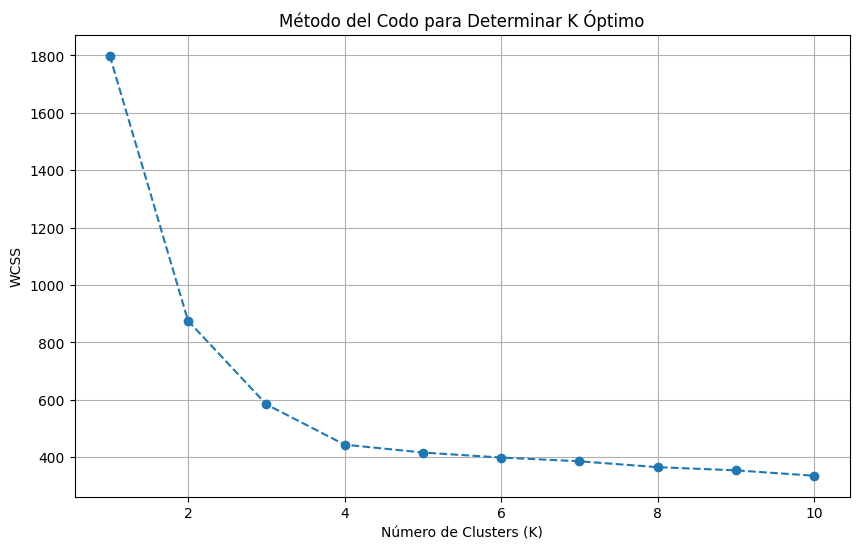

In [8]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Lista para almacenar los valores de WCSS (Within-Cluster Sum of Squares)
wcss = []

# Probar diferentes números de clusters (por ejemplo, de 1 a 10)
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=42)
    kmeans.fit(df_scaled)
    wcss.append(kmeans.inertia_)

# Graficar el método del codo
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Método del Codo para Determinar K Óptimo')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()


### Paso 6: Aplicar K-Means con el Número Óptimo de Grupos (K=4)

Una vez identificado el número óptimo de clusters (en este caso, 4, según la interpretación del método del codo), procederemos a aplicar el algoritmo K-Means a los datos escalados. K-Means asignará cada punto de datos a uno de los 4 clusters, buscando minimizar la inercia dentro de cada cluster.

In [9]:
from sklearn.cluster import KMeans

# Establecer el número óptimo de clusters
optimal_k = 4

# Inicializar y ajustar el modelo K-Means a los datos escalados
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', max_iter=300, n_init=10, random_state=42)
kmeans.fit(df_scaled)

# Obtener las etiquetas de los clusters
cluster_labels = kmeans.labels_

# Crear una copia limpia del DataFrame original antes de añadir la columna de cluster
# Esto es importante porque 'df_clustering_cleaned' puede tener menos filas si se eliminaron NaNs.
# Necesitamos mapear las etiquetas de cluster a las filas originales correspondientes.
# Si df_clustering_cleaned tiene la misma cantidad de filas que df (sin NaNs), podemos simplemente añadir la columna.
# Asumiendo que df_clustering_cleaned mantiene el índice original de df

df_with_clusters = df_clustering_cleaned.copy()
df_with_clusters['cluster'] = cluster_labels

# Opcionalmente, puedes unir esto de nuevo al DataFrame original si 'registro_id' no fue descartado
# Para este ejercicio, vamos a trabajar con df_with_clusters que contiene las variables limpiadas y escaladas
# unidas con las etiquetas de cluster.

# Mostrar las primeras filas del DataFrame con la nueva columna de clusters
print("DataFrame con las etiquetas de clusters (primeras 5 filas):")
print(df_with_clusters.head())


DataFrame con las etiquetas de clusters (primeras 5 filas):
   edad  ingresos  frecuencia_uso  gasto_promedio  satisfaccion  reclamos  \
0    48      1292            9.60          158.47          8.45         0   
1    39       707            6.72           73.85          2.99         6   
2    37      1100            4.02           79.86          3.68         4   
3    35       582            3.25           44.88          5.18        12   
4    37      1191            6.66           55.80          7.96         1   

   antiguedad_meses  cluster  
0                37        0  
1                 1        3  
2                 4        3  
3                 8        3  
4                23        2  


### Paso 7: Visualizar los Grupos mediante Gráficos

Para visualizar los grupos en un espacio bidimensional, utilizaremos el Análisis de Componentes Principales (PCA). PCA nos ayudará a reducir la dimensionalidad de nuestros datos manteniendo la mayor parte de la varianza, lo que nos permitirá graficar los clusters y observar su separación.

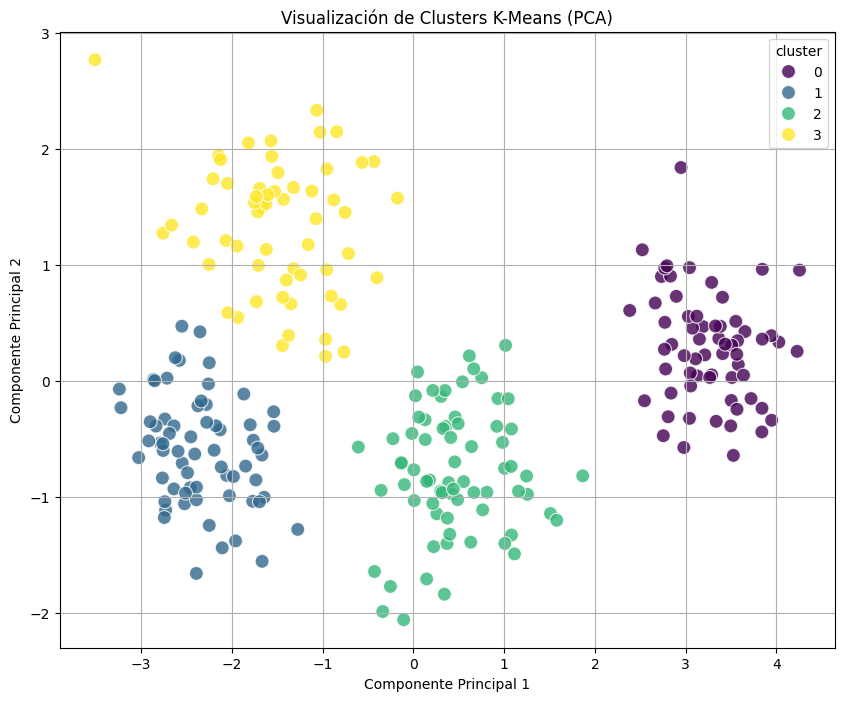

In [10]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Aplicar PCA para reducir los datos a 2 componentes principales para visualización
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_scaled)

# Crear un DataFrame con los componentes principales y las etiquetas de cluster
df_pca_with_clusters = pd.DataFrame(data=df_pca, columns=['PC1', 'PC2'])
df_pca_with_clusters['cluster'] = cluster_labels

# Visualizar los clusters
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x='PC1', y='PC2', hue='cluster', data=df_pca_with_clusters,
    palette='viridis', s=100, alpha=0.8, legend='full'
)
plt.title('Visualización de Clusters K-Means (PCA)')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.grid(True)
plt.show()


### Paso 8: Interpretar cada Grupo Encontrado

Para interpretar cada grupo, calcularemos las medias de las variables originales para cada cluster. Esto nos permitirá entender las características distintivas de los clientes en cada segmento.

In [11]:
# Antes de calcular las medias de los clusters, debemos asegurarnos de que el DataFrame
# 'df' original se utiliza para la interpretación, pero con las etiquetas de cluster
# correspondientes a las filas que no fueron eliminadas por NaN.

# Unimos las etiquetas de cluster a df_clustering_cleaned, que es el DataFrame original
# sin NaNs, y que fue el que se usó para escalar y clusterizar.

df_final = df_clustering_cleaned.copy()
df_final['cluster'] = cluster_labels

# Calcular las medias de las variables para cada cluster
cluster_means = df_final.groupby('cluster').mean()

print("Medias de las variables por Cluster:")
print(cluster_means)


Medias de las variables por Cluster:
              edad     ingresos  frecuencia_uso  gasto_promedio  satisfaccion  \
cluster                                                                         
0        53.587302  1740.698413        9.090159      158.034286      8.801905   
1        28.984615   683.230769        2.390154       37.215231      6.028308   
2        38.704225  1117.690141        6.591690       86.681690      8.083380   
3        42.913793   950.275862        4.348793       60.632414      4.600690   

         reclamos  antiguedad_meses  
cluster                              
0        0.777778         36.523810  
1        3.169231          5.000000  
2        1.253521         17.647887  
3        4.931034         12.344828  
